Supermart Grocery Sales - Retail Analytics Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#reading csv file
df = pd.read_csv("Supermart Grocery Sales - Retail Analytics Dataset.csv")
df.sample(5)

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
5697,OD5698,Alan,Fruits & Veggies,Fresh Vegetables,Karur,3/19/2015,South,824,0.28,230.72,Tamil Nadu
4791,OD4792,Ram,Food Grains,Dals & Pulses,Bodi,7/18/2018,West,2430,0.29,170.10,Tamil Nadu
354,OD355,Surya,Bakery,Biscuits,Kanyakumari,04-08-2017,East,743,0.35,289.77,Tamil Nadu
3804,OD3805,Ramesh,Bakery,Biscuits,Tenkasi,12/14/2015,East,1050,0.25,252.00,Tamil Nadu
3101,OD3102,Veronica,Fruits & Veggies,Organic Fruits,Bodi,12/29/2017,West,621,0.10,279.45,Tamil Nadu


In [3]:
#dropping useless column
df.drop(["Order ID"], axis= 1, inplace=True)

In [4]:
#viewing the row and column or shape
df.shape

(9994, 10)

In [5]:
#viewing the size of the dataframe
df.size

99940

In [6]:
#viewing the columns in dataframe
df.columns

Index(['Customer Name', 'Category', 'Sub Category', 'City', 'Order Date',
       'Region', 'Sales', 'Discount', 'Profit', 'State'],
      dtype='str')

In [7]:
#gathering the info of the df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer Name  9994 non-null   str    
 1   Category       9994 non-null   str    
 2   Sub Category   9994 non-null   str    
 3   City           9994 non-null   str    
 4   Order Date     9994 non-null   str    
 5   Region         9994 non-null   str    
 6   Sales          9994 non-null   int64  
 7   Discount       9994 non-null   float64
 8   Profit         9994 non-null   float64
 9   State          9994 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 780.9 KB


In [8]:
#Viewing the total null value in dataframe
df.isna().sum()

Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

In [9]:
#seeing the unique values in the customer name column
df["Customer Name"].unique()


<StringArray>
[  'Harish',    'Sudha',  'Hussain',  'Jackson',  'Ridhesh',   'Adavan',
    'Jonas',    'Hafiz', 'Krithika',   'Ganesh',    'Yadav',   'Sharon',
     'Peer',   'Sundar',   'Ramesh',     'Alan',   'Arutra',  'Haseena',
    'Verma',   'Muneer', 'Veronica',     'Shah',   'Mathew',    'Akash',
      'Anu',  'Sabeela',    'James',  'Willams',    'Malik',   'Amrish',
    'Vince',   'Suresh',   'Esther',    'Yusuf',    'Komal',    'Veena',
    'Shree',   'Roshan',   'Sudeep',    'Vinne',    'Vidya',   'Arvind',
    'Kumar',      'Amy',     'Ravi',   'Sheeba',      'Ram',  'Rumaiza',
    'Aditi',    'Surya']
Length: 50, dtype: str

In [10]:
df["Category"].unique()

<StringArray>
[     'Oil & Masala',         'Beverages',       'Food Grains',
  'Fruits & Veggies',            'Bakery',            'Snacks',
 'Eggs, Meat & Fish']
Length: 7, dtype: str

In [11]:
df["Sub Category"].unique()

<StringArray>
[           'Masalas',      'Health Drinks',       'Atta & Flour',
   'Fresh Vegetables',    'Organic Staples',       'Fresh Fruits',
           'Biscuits',              'Cakes',         'Chocolates',
               'Eggs',            'Cookies',            'Chicken',
  'Edible Oil & Ghee',             'Mutton',        'Soft Drinks',
      'Dals & Pulses', 'Organic Vegetables',            'Noodles',
     'Organic Fruits',               'Fish',             'Spices',
               'Rice',      'Breads & Buns']
Length: 23, dtype: str

In [12]:
df["City"].unique()

<StringArray>
[       'Vellore',    'Krishnagiri',     'Perambalur',     'Dharmapuri',
           'Ooty',         'Trichy', 'Ramanadhapuram',    'Tirunelveli',
        'Chennai',          'Karur',       'Namakkal',       'Dindigul',
    'Kanyakumari',           'Bodi',        'Tenkasi',     'Viluppuram',
        'Madurai',          'Salem',         'Cumbum',      'Nagercoil',
     'Pudukottai',          'Theni',     'Coimbatore',   'Virudhunagar']
Length: 24, dtype: str

In [13]:
df["Region"].unique()

<StringArray>
['North', 'South', 'West', 'Central', 'East']
Length: 5, dtype: str

In [14]:
df["Order Date"].sample(5)

8833    10-06-2017
4868    12/15/2016
8587    11-09-2015
7349     8/24/2018
9759    11-12-2018
Name: Order Date, dtype: str

In [15]:
#After viewing the irreugular date. 
#This line converts the "Order Date" column in your pandas DataFrame from strings into actual datetime objects.
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Order Date"].sample(5)

2334   2018-06-10
5197   2018-11-23
5548   2018-09-19
5478   2018-11-17
6177   2015-03-22
Name: Order Date, dtype: datetime64[us]

In [16]:
#Extracting year, month, date from the order date column
df['Year'] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Date"] = df["Order Date"]. dt.day


In [20]:
'''i am extracting discount amount from the discount percentage by using the simple formula: CP = (SP*100/ 100-Discount percent)
and then we are subtracting CP from SP to get discount amount '''

df["Discount_Amt"] = round((df["Sales"]*100)/(100-(df["Discount"]*100))).astype(int) - df["Sales"]

In [21]:
#removing the order date column
df.drop(["Order Date", "Discount"], axis=1, inplace=True)

In [23]:
#final dataframe
df.head(6)

,Customer Name,Category,Sub Category,City,Region,Sales,Profit,State,Year,Month,Date,Discount_Amt
0,Harish,Oil & Masala,Masalas,Vellore,North,1254,401.28,Tamil Nadu,2017,November,8,171
1,Sudha,Beverages,Health Drinks,Krishnagiri,South,749,149.80,Tamil Nadu,2017,November,8,164
2,Hussain,Food Grains,Atta & Flour,Perambalur,West,2360,165.20,Tamil Nadu,2017,June,12,627
3,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,South,896,89.60,Tamil Nadu,2016,October,11,299
4,Ridhesh,Food Grains,Organic Staples,Ooty,South,2355,918.45,Tamil Nadu,2016,October,11,827
5,Adavan,Food Grains,Organic Staples,Dharmapuri,West,2305,322.70,Tamil Nadu,2015,June,9,810


In [24]:
#count of product sold in each Category
df["Category"].value_counts()

Category
Snacks               1514
Eggs, Meat & Fish    1490
Fruits & Veggies     1418
Bakery               1413
Beverages            1400
Food Grains          1398
Oil & Masala         1361
Name: count, dtype: int64

In [25]:
# Count of products sold in each Sub Category
df["Sub Category"].value_counts()

Sub Category
Health Drinks         719
Soft Drinks           681
Cookies               520
Breads & Buns         502
Chocolates            499
Noodles               495
Masalas               463
Biscuits              459
Cakes                 452
Edible Oil & Ghee     451
Spices                447
Mutton                394
Eggs                  379
Organic Staples       372
Fresh Fruits          369
Fish                  369
Fresh Vegetables      354
Atta & Flour          353
Chicken               348
Organic Fruits        348
Organic Vegetables    347
Dals & Pulses         343
Rice                  330
Name: count, dtype: int64

In [26]:
# Count of products sold in each City
df["City"].value_counts()

City
Kanyakumari       459
Tirunelveli       446
Bodi              442
Krishnagiri       440
Vellore           435
Perambalur        434
Chennai           432
Tenkasi           432
Salem             431
Karur             430
Pudukottai        430
Coimbatore        428
Ramanadhapuram    421
Cumbum            417
Virudhunagar      416
Madurai           408
Ooty              404
Namakkal          403
Viluppuram        397
Dindigul          396
Theni             387
Dharmapuri        376
Nagercoil         373
Trichy            357
Name: count, dtype: int64

In [27]:
df["Region"].value_counts()

Region
West       3203
East       2848
Central    2323
South      1619
North         1
Name: count, dtype: int64

In [28]:
#filtering out the north from the dataframe because it only have one value
df = df[df["Region"] != "North"]

In [29]:
# Count of products sold in each Region after transformation
df["Region"].value_counts()

Region
West       3203
East       2848
Central    2323
South      1619
Name: count, dtype: int64

In [30]:
# Count of products sold each Year
df["Year"].value_counts()

Year
2018    3312
2017    2586
2016    2102
2015    1993
Name: count, dtype: int64

In [31]:
# Count of products sold each Month
df["Month"].value_counts()


Month
November     1470
December     1408
September    1383
October       819
May           735
June          717
July          710
August        706
March         696
April         668
January       381
February      300
Name: count, dtype: int64

In [32]:
# Count of products sold each Date
df["Date"].value_counts()

Date
20    398
21    396
2     379
5     366
26    365
3     365
11    359
23    358
8     355
17    352
14    348
12    345
9     344
13    338
1     337
19    335
25    334
18    328
4     308
24    302
10    300
7     298
30    295
28    285
6     285
22    284
27    273
15    271
16    269
29    238
31    183
Name: count, dtype: int64

In [33]:
# Total sale in each Category
df.groupby(["Category"])["Sales"].sum().sort_values(ascending=False)

Category
Eggs, Meat & Fish    2267401
Snacks               2237546
Food Grains          2115272
Bakery               2112281
Fruits & Veggies     2100727
Beverages            2085313
Oil & Masala         2037188
Name: Sales, dtype: int64

In [37]:
# Total sale in each Sub Category
df.groupby(["Sub Category"])["Sales"].sum().sort_values(ascending=False)

Sub Category
Health Drinks         1051439
Soft Drinks           1033874
Cookies                768213
Breads & Buns          742586
Noodles                735435
Chocolates             733898
Masalas                696226
Cakes                  685612
Biscuits               684083
Spices                 672876
Edible Oil & Ghee      668086
Mutton                 611200
Eggs                   575156
Fish                   560548
Organic Staples        558929
Fresh Fruits           551212
Atta & Flour           534649
Fresh Vegetables       525842
Dals & Pulses          523371
Chicken                520497
Organic Vegetables     520271
Organic Fruits         503402
Rice                   498323
Name: Sales, dtype: int64

In [39]:
# Total sale in each Region
df.groupby(["Region"])["Sales"].sum().sort_values(ascending=False)


Region
West       4798743
East       4248368
Central    3468156
South      2440461
Name: Sales, dtype: int64

In [41]:
# Total sale in each City
df.groupby(["City"])["Sales"].sum().sort_values(ascending=False)

City
Kanyakumari       706764
Vellore           675296
Bodi              667177
Tirunelveli       659812
Perambalur        659738
Salem             657093
Pudukottai        653179
Tenkasi           643652
Karur             642273
Krishnagiri       637273
Chennai           634963
Coimbatore        634748
Ramanadhapuram    634386
Cumbum            626047
Madurai           617836
Virudhunagar      606820
Ooty              599292
Namakkal          598530
Viluppuram        581274
Theni             579553
Dindigul          575631
Dharmapuri        571553
Nagercoil         551435
Trichy            541403
Name: Sales, dtype: int64

In [42]:
df.groupby(["Month"])["Sales"].sum().sort_values(ascending=False)

Month
November     2192670
December     2088076
September    2064266
October      1243289
July         1089385
May          1086920
June         1057808
March        1053980
August       1046807
April         998453
January       577972
February      456102
Name: Sales, dtype: int64

In [43]:
# Total sale in each Year
df.groupby(["Year"])["Sales"].sum().sort_values(ascending=False)

Year
2018    4977512
2017    3870658
2016    3131959
2015    2975599
Name: Sales, dtype: int64

In [44]:
# Total profit in each Category
df.groupby(["Category"])["Profit"].sum().sort_values(ascending=False)

Category
Snacks               568178.85
Eggs, Meat & Fish    567357.22
Fruits & Veggies     530400.38
Food Grains          529162.64
Bakery               528521.06
Beverages            525605.76
Oil & Masala         497494.01
Name: Profit, dtype: float64

In [45]:
# Total profit in each Sub Category
df.groupby(["Sub Category"])["Profit"].sum().sort_values(ascending=False)

Sub Category
Health Drinks         267469.79
Soft Drinks           258135.97
Noodles               193685.81
Breads & Buns         190764.98
Cookies               190643.70
Chocolates            183849.34
Biscuits              169357.62
Masalas               168597.83
Edible Oil & Ghee     168593.58
Cakes                 168398.46
Spices                160302.60
Mutton                151389.40
Fish                  147248.01
Eggs                  144669.92
Organic Staples       144136.89
Fresh Fruits          134668.35
Organic Vegetables    133596.37
Fresh Vegetables      131273.33
Organic Fruits        130862.33
Dals & Pulses         130232.29
Atta & Flour          127861.10
Rice                  126932.36
Chicken               124049.89
Name: Profit, dtype: float64

In [46]:
# Total profit in each Region
df.groupby(["Region"])["Profit"].sum().sort_values(ascending=False)

Region
West       1192004.61
East       1074345.58
Central     856806.84
South       623562.89
Name: Profit, dtype: float64

In [47]:
# Total profit in each City
df.groupby(["City"])["Profit"].sum().sort_values(ascending=False)

City
Vellore           173671.73
Bodi              173655.13
Kanyakumari       172217.74
Perambalur        171132.19
Karur             169305.94
Tirunelveli       165169.01
Pudukottai        164072.63
Chennai           160921.33
Salem             160899.30
Krishnagiri       160477.48
Ramanadhapuram    158951.03
Coimbatore        157399.41
Cumbum            156355.13
Tenkasi           156230.72
Madurai           152548.61
Virudhunagar      150816.69
Ooty              150078.92
Namakkal          145502.10
Dindigul          144872.95
Viluppuram        144200.64
Theni             142739.78
Dharmapuri        141593.05
Nagercoil         137848.47
Trichy            136059.94
Name: Profit, dtype: float64

In [48]:
# Total profit in each Month
df.groupby(["Month"])["Profit"].sum().sort_values(ascending=False)

Month
November     555646.77
December     530036.44
September    517788.56
October      309376.90
July         274594.57
March        267347.33
May          263643.40
June         263296.16
August       258912.09
April        247476.97
January      142518.52
February     116082.21
Name: Profit, dtype: float64

In [49]:
# Total profit in each Year
df.groupby(["Year"])["Profit"].sum().sort_values(ascending=False)

Year
2018    1244182.88
2017     952814.94
2016     797192.99
2015     752529.11
Name: Profit, dtype: float64

In [50]:
# Customer's with highest total orders
df.groupby(["Customer Name"])["Sales"].sum().sort_values(ascending=False).head(10)

Customer Name
Krithika    334361
Amrish      333351
Verma       331665
Arutra      325720
Vidya       321798
Vinne       319565
Shah        318588
Suresh      315973
Adavan      315341
Surya       312645
Name: Sales, dtype: int64

In [51]:
# Most purchased product from each category by Customer's
df.groupby(["Customer Name","Category"])["Category"].count().sort_values(ascending=False).head(10)

Customer Name  Category         
Veronica       Fruits & Veggies     43
Amrish         Bakery               42
Yusuf          Oil & Masala         42
Ganesh         Snacks               42
Vidya          Eggs, Meat & Fish    41
Verma          Eggs, Meat & Fish    41
Amrish         Food Grains          40
Shah           Bakery               40
Ram            Beverages            40
Vinne          Snacks               40
Name: Category, dtype: int64

In [52]:
# Most purchased product from each sub category by Customer's
df.groupby(["Customer Name","Sub Category"])["Sub Category"].count().sort_values(ascending=False).head(10)

Customer Name  Sub Category 
Yadav          Soft Drinks      23
Amy            Health Drinks    22
Ram            Health Drinks    22
Veena          Soft Drinks      21
Ridhesh        Soft Drinks      20
James          Health Drinks    20
Krithika       Cakes            20
Rumaiza        Soft Drinks      20
Amrish         Health Drinks    19
Alan           Cookies          19
Name: Sub Category, dtype: int64

In [53]:
# Most order placed from different cities by Customer's
df.groupby(["Customer Name","City"])["City"].count().sort_values(ascending=False).head(10)

Customer Name  City          
Sharon         Ooty              20
Amrish         Viluppuram        18
Sudeep         Madurai           18
James          Ramanadhapuram    18
Esther         Virudhunagar      17
Veronica       Tenkasi           16
Yadav          Perambalur        16
Jonas          Cumbum            16
Ravi           Ramanadhapuram    16
Verma          Cumbum            16
Name: City, dtype: int64

In [54]:
# Most order placed from different regions by Customer's
df.groupby(["Customer Name","Region"])["Region"].count().sort_values(ascending=False).head(10)

Customer Name  Region
Krithika       West      90
Malik          West      77
Veena          West      76
Mathew         West      75
Veronica       West      75
Arutra         West      74
Peer           West      73
Amrish         West      73
Krithika       East      73
Muneer         West      73
Name: Region, dtype: int64

In [55]:
# Most order placed in different months by Customer's
df.groupby(["Customer Name","Month"])["Month"].count().sort_values(ascending=False).head(10)

Customer Name  Month    
Krithika       December     42
Veronica       September    41
Yusuf          November     41
Hussain        November     40
Vinne          December     39
Arutra         December     39
Akash          September    37
Komal          September    37
Hussain        December     37
Sudeep         November     37
Name: Month, dtype: int64

In [56]:
# Most order placed in different years by Customer's
df.groupby(["Customer Name","Year"])["Year"].count().sort_values(ascending=False).head(10)

Customer Name  Year
Suresh         2018    80
Adavan         2018    79
Surya          2018    77
Verma          2018    76
Ram            2018    74
Veronica       2018    73
Krithika       2018    72
Akash          2018    72
Vidya          2018    72
Ravi           2018    72
Name: Year, dtype: int64

In [57]:
# Total Discount on each Product Category
df.groupby(["Category"])["Discount_Amt"].sum().sort_values(ascending=False)

Category
Eggs, Meat & Fish    694041
Snacks               663963
Food Grains          652872
Fruits & Veggies     650275
Beverages            648970
Bakery               638128
Oil & Masala         617326
Name: Discount_Amt, dtype: int64

In [58]:
# Total Discount on each Sub Product Category
df.groupby(["Sub Category"])["Discount_Amt"].sum().sort_values(ascending=False)

Sub Category
Health Drinks         328816
Soft Drinks           320154
Breads & Buns         226696
Cookies               224374
Chocolates            221921
Noodles               217668
Edible Oil & Ghee     209592
Masalas               207747
Cakes                 206505
Biscuits              204927
Spices                199987
Mutton                185879
Organic Staples       175957
Fish                  175879
Eggs                  173843
Fresh Fruits          167977
Organic Vegetables    164475
Atta & Flour          163358
Fresh Vegetables      162803
Dals & Pulses         158886
Chicken               158440
Organic Fruits        155020
Rice                  154671
Name: Discount_Amt, dtype: int64

In [59]:
# Total Discount in each Region
df.groupby(["Region"])["Discount_Amt"].sum().sort_values(ascending=False)

Region
West       1450419
East       1300786
Central    1068850
South       745520
Name: Discount_Amt, dtype: int64

In [60]:
# Total Discount in each City
df.groupby(["City"])["Discount_Amt"].sum().sort_values(ascending=False)

City
Vellore           212268
Kanyakumari       211570
Perambalur        207825
Tirunelveli       200610
Tenkasi           199804
Salem             197370
Karur             195645
Pudukottai        195166
Ramanadhapuram    194399
Chennai           194311
Cumbum            193613
Bodi              193461
Krishnagiri       191242
Madurai           187467
Coimbatore        186064
Namakkal          184304
Theni             181967
Ooty              180596
Viluppuram        180388
Dharmapuri        179366
Virudhunagar      178404
Trichy            174857
Nagercoil         174267
Dindigul          170611
Name: Discount_Amt, dtype: int64

In [61]:
# Total Discount in each Month
df.groupby(["Month"])["Discount_Amt"].sum().sort_values(ascending=False)


Month
November     674780
December     630591
September    629729
October      382904
July         339438
May          327797
June         326871
March        324026
August       318511
April        303432
January      175569
February     131927
Name: Discount_Amt, dtype: int64

In [62]:
# Total Discount in each Year
df.groupby(["Year"])["Discount_Amt"].sum().sort_values(ascending=False)

Year
2018    1509381
2017    1181457
2016     961588
2015     913149
Name: Discount_Amt, dtype: int64

In [63]:
# Customer's with most Discount
df.groupby(["Customer Name"])["Discount_Amt"].sum().sort_values(ascending=False).head(10)

Customer Name
Verma       108213
Amrish      103100
Muneer       99528
Vinne        99354
Shah         99249
Krithika     97860
Sheeba       97108
Hussain      96853
Arutra       96494
Mathew       96277
Name: Discount_Amt, dtype: int64

In [64]:
# Sale of Different Category Products Year Wise
df.pivot_table(index="Year", columns="Category", values="Sales", aggfunc="sum")

Category,Bakery,Beverages,"Eggs, Meat & Fish",Food Grains,Fruits & Veggies,Oil & Masala,Snacks
Year,,,,,,,
2015,433979,409091,482982,356704,409212,423918,459713
2016,487965,425719,462055,438736,468441,412725,436318
2017,504263,543575,565101,609338,516400,562942,569039
2018,686074,706928,757263,710494,706674,637603,772476


In [65]:
# Sale of Different Category Products Month Wise
df.pivot_table(index="Month", columns="Category", values="Sales", aggfunc="sum")

Category,Bakery,Beverages,"Eggs, Meat & Fish",Food Grains,Fruits & Veggies,Oil & Masala,Snacks
Month,,,,,,,
April,123181,151748,143530,128790,138084,157369,155751
August,162277,152976,149694,182850,140885,124935,133190
December,298939,265806,344238,291656,311754,270309,305374
February,54701,60188,58331,62983,74313,62044,83542
January,69139,91775,74158,79531,80753,95324,87292
July,168795,137856,151179,166926,162689,149179,152761
June,154397,140633,181754,128165,153431,129080,170348
March,154253,143575,165977,140169,126704,142637,180665
May,135113,163490,173024,143356,152491,182725,136721


In [66]:
# Sale of Different Category Products Region Wise
df.pivot_table(index="Region", columns="Category", values="Sales", aggfunc="sum")

Category,Bakery,Beverages,"Eggs, Meat & Fish",Food Grains,Fruits & Veggies,Oil & Masala,Snacks
Region,,,,,,,
Central,448343,501194,516642,463683,526507,453293,558494
East,588241,577206,677830,598868,564237,622071,619915
South,361385,344666,360963,353069,352162,298859,369357
West,714312,662247,711966,699652,657821,662965,689780


In [67]:
# Profit from Different Category Products Year Wise
df.pivot_table(index="Year", columns="Category", values="Profit", aggfunc="sum")

Category,Bakery,Beverages,"Eggs, Meat & Fish",Food Grains,Fruits & Veggies,Oil & Masala,Snacks
Year,,,,,,,
2015,107567.44,104834.61,126057.88,90837.84,100586.06,105637.64,117007.64
2016,124536.04,110201.14,114208.28,113643.27,118900.21,102656.22,113047.83
2017,122078.77,135179.89,135896.22,149775.58,130630.77,137156.83,142096.88
2018,174338.81,175390.12,191194.84,174905.95,180283.34,152043.32,196026.50


In [68]:
# Profit from Different Category Products Month Wise
df.pivot_table(index="Month", columns="Category", values="Profit", aggfunc="sum")

Category,Bakery,Beverages,"Eggs, Meat & Fish",Food Grains,Fruits & Veggies,Oil & Masala,Snacks
Month,,,,,,,
April,28491.68,38426.16,37453.93,31279.89,37907.45,36273.10,37644.76
August,40395.81,40139.14,38057.70,42734.55,34780.18,30230.38,32574.33
December,74036.37,67086.34,86623.79,75671.33,76006.63,71378.32,79233.66
February,12636.04,15080.17,15089.23,14680.57,19410.95,17374.45,21810.80
January,18555.36,23958.38,17714.58,18795.67,21362.53,22117.10,20014.90
July,39733.87,35285.65,40908.34,42397.92,40517.79,37037.06,38713.94
June,38539.89,36220.45,44216.92,31192.94,39272.91,31764.42,42088.63
March,42785.93,38049.03,43155.74,32659.45,30729.94,36544.52,43422.72
May,31426.63,38256.46,44998.40,35674.88,38603.40,41634.13,33049.50


In [69]:
# Profit from Different Category Products Region Wise
df.pivot_table(index="Region", columns="Category", values="Profit", aggfunc="sum")

Category,Bakery,Beverages,"Eggs, Meat & Fish",Food Grains,Fruits & Veggies,Oil & Masala,Snacks
Region,,,,,,,
Central,109543.91,128017.14,126587.35,111517.05,131699.53,109261.91,140179.95
East,153741.06,144498.17,164465.08,154932.01,141292.78,155569.22,159847.26
South,89102.07,84058.78,93728.18,94823.55,92961.26,73909.18,94979.87
West,176134.02,169031.67,182576.61,167890.03,164446.81,158753.70,173171.77


In [70]:
# Percent of total revenue spend on Discounts
amt_spend = int(df["Discount_Amt"].sum()/df["Sales"].sum()*100)
print(f"{amt_spend}% of total revenue was spend on Discounts.")

30% of total revenue was spend on Discounts.


In [71]:
# Setting Plot Style to "ticks"
sns.set_style("ticks")

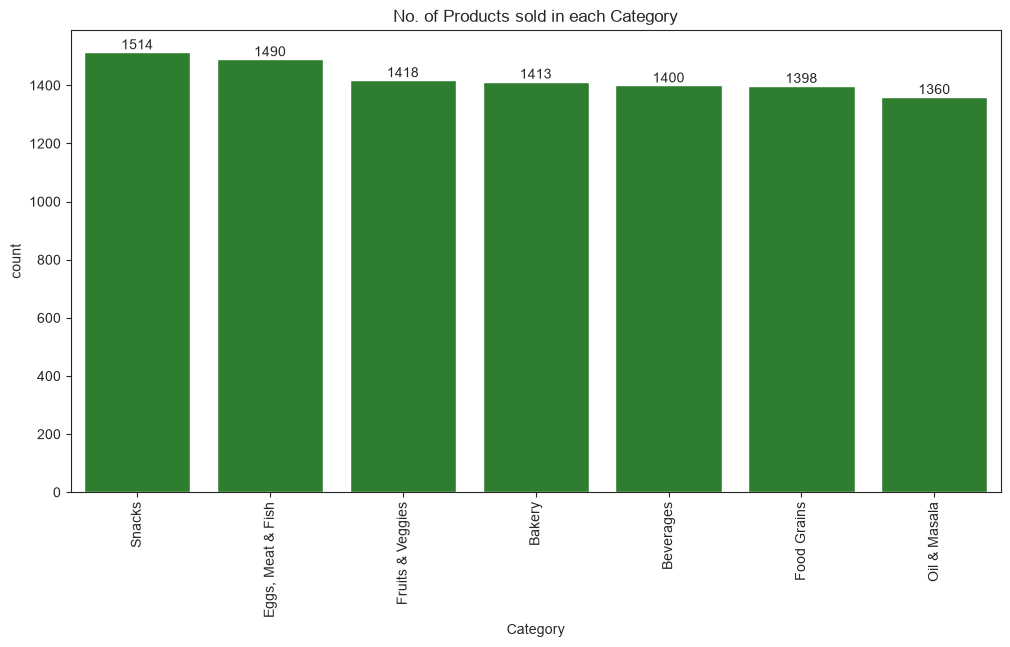

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x="Category", color="#228B22", order=df["Category"].value_counts().index)
ax.set_title("No. of Products sold in each Category")
ax.tick_params(axis="x", rotation=90)
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

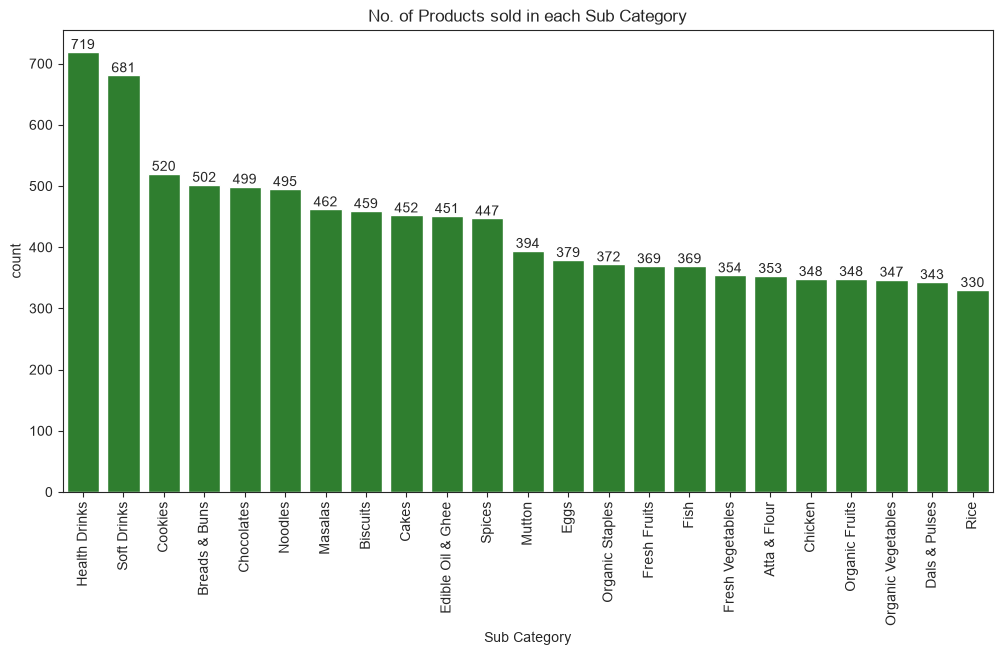

In [73]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x="Sub Category", color="#228B22", order=df["Sub Category"].value_counts().index)
ax.set_title("No. of Products sold in each Sub Category")
ax.tick_params(axis='x', rotation=90)
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

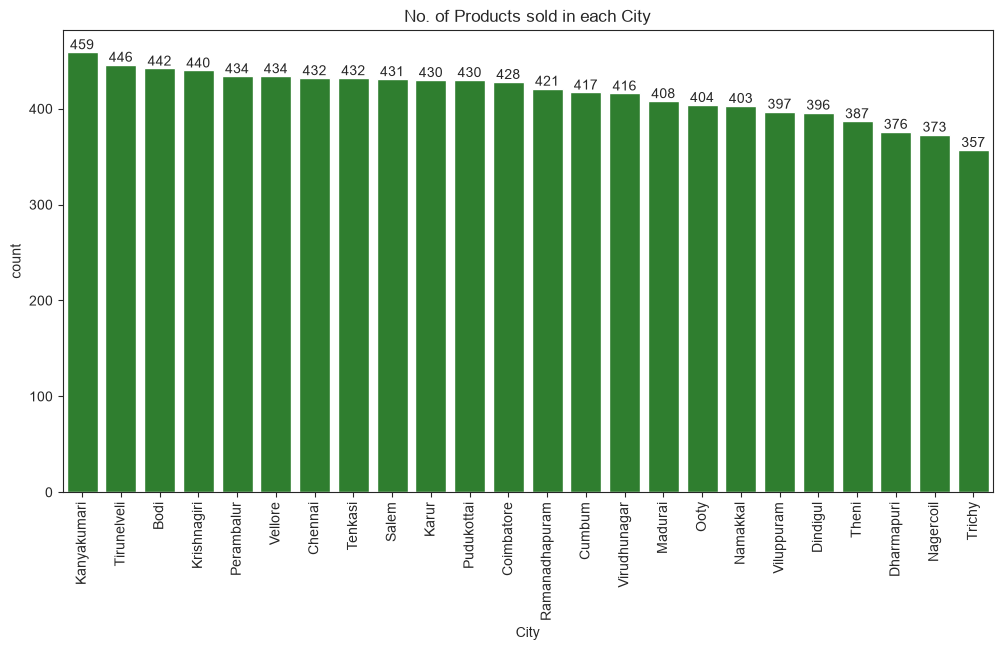

In [74]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x="City", color="#228B22", order=df["City"].value_counts().index)
ax.set_title("No. of Products sold in each City")
ax.tick_params(axis='x', rotation=90)
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

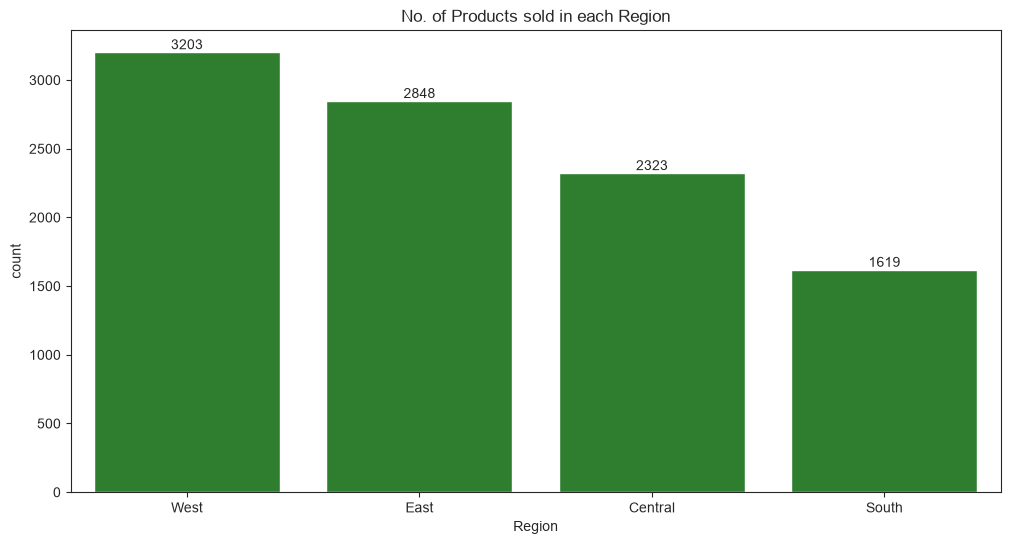

In [75]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x="Region", color="#228B22", order=df["Region"].value_counts().index)
ax.set_title("No. of Products sold in each Region")
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

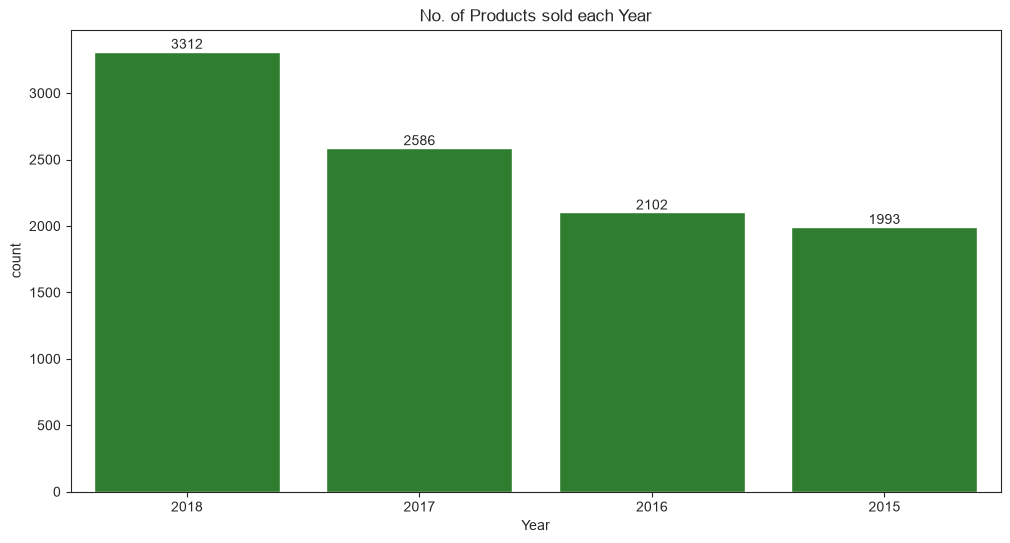

In [76]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x="Year", color="#228B22", order=df["Year"].value_counts().index)
ax.set_title("No. of Products sold each Year")
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

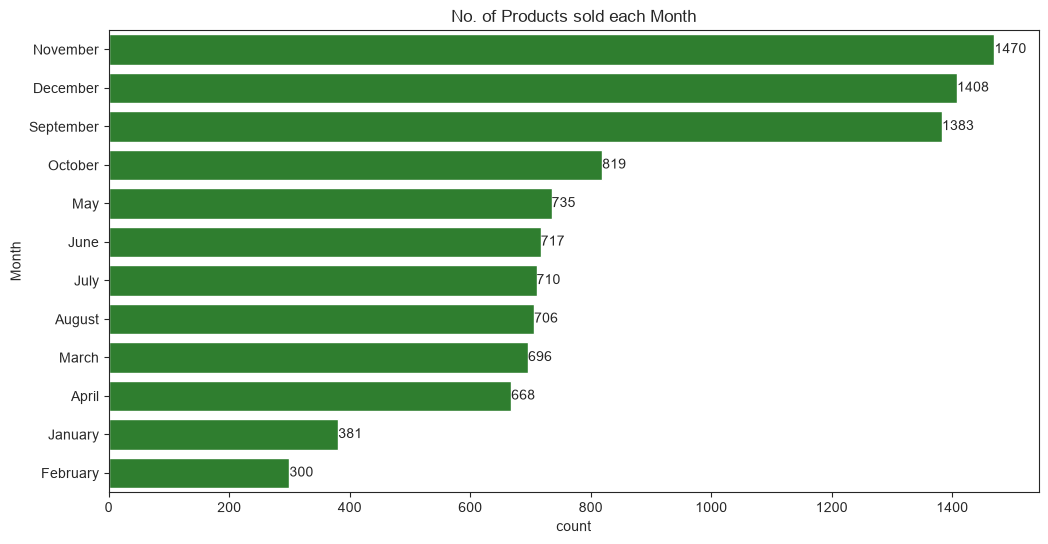

In [77]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, y="Month", color="#228B22", order=df["Month"].value_counts().index)
ax.set_title("No. of Products sold each Month")
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

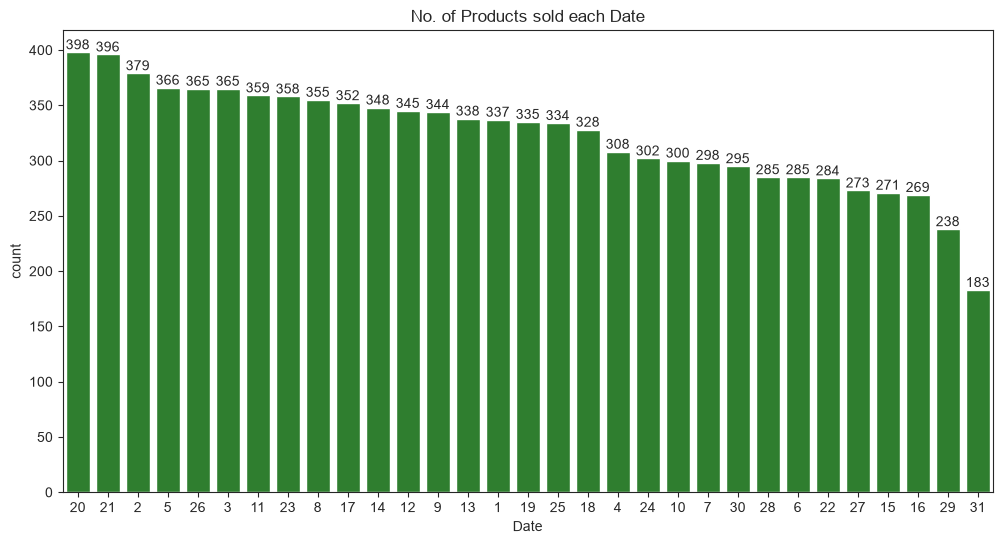

In [78]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x="Date", color="#228B22", order=df["Date"].value_counts().index)
ax.set_title("No. of Products sold each Date")
ax.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [79]:
sales_by_category = df.groupby(["Category"])["Sales"].sum().sort_values(ascending=False)

Text(0.5, 1.0, 'Total sales in each Category')

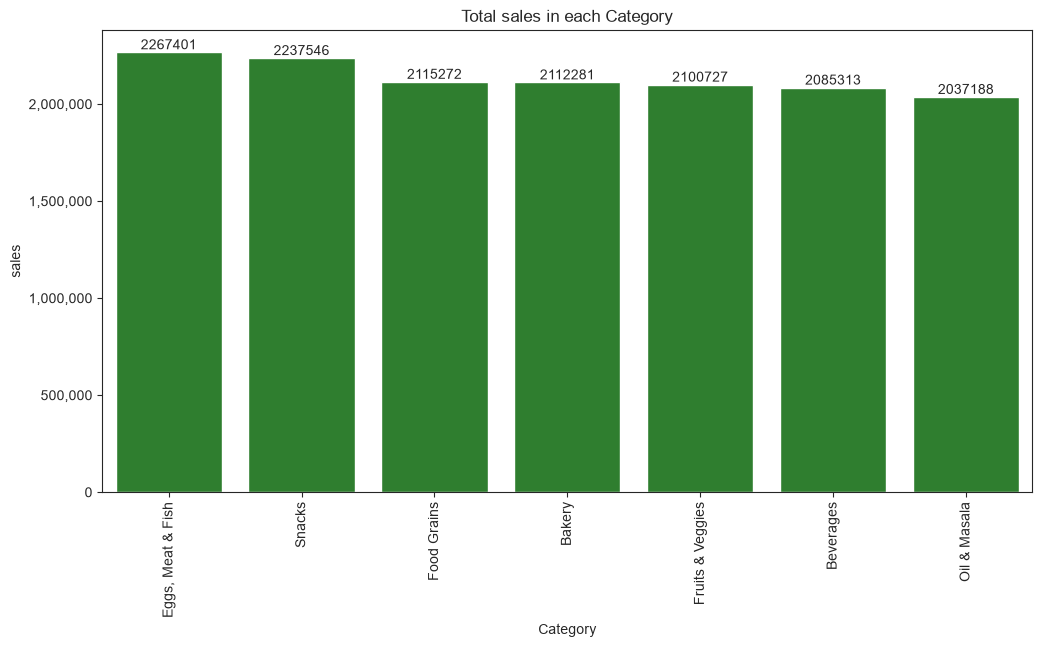

In [80]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, 
            color="#228B22", order=df.groupby(["Category"])["Sales"].sum().sort_values(ascending=False).index)

formatter = FuncFormatter(lambda x, _: f'{int(x):,}')
ax.yaxis.set_major_formatter(formatter)

ax.set_ylabel('sales')
ax.tick_params(axis="x", rotation=90)
ax.bar_label(ax.containers[0], fmt='%d')
ax.set_title("Total sales in each Category")


In [81]:
sales_by_sub_category = df.groupby(["Sub Category"])["Sales"].sum().sort_values(ascending=False)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=sales_by_sub_category.index, y=sales_by_sub_category.values, 
            color="#228B22", order=df.groupby(["Sub Category"])["Sales"].sum().sort_values(ascending=False).index)

formatter = FuncFormatter(lambda x, _: f'{int(x):,}')
ax.yaxis.set_major_formatter(formatter)

ax.set_ylabel('sales')
ax.tick_params(axis='x', rotation=90)
ax.set_title("Total sales in each Sub Category")

plt.show()